<a href="https://colab.research.google.com/github/chavacodezen/Maestria-IA/blob/main/Proyecto_Etapa_2_An%C3%A1lisis_Exploratorio_de_Datos_(EDA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 👤 **Estudiante**
- **Nombre:** Bryan Fernando Chavarria Martinez  
- **Matrícula:** 268838

# **ACTIVIDAD — Proyecto Etapa 2: Análisis Exploratorio de Datos (EDA)**

## 🎯 **Objetivo**
Realizar un Análisis Exploratorio de Datos (EDA) utilizando Python en Google Colab, aplicando técnicas de preprocesamiento, estadística descriptiva y visualización para identificar patrones, relaciones y problemas en los datos.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv("drive/MyDrive/ClassFiles/Unidad02/Project_Oracle_Db.csv")

Mounted at /content/drive


## **1. Descripción del dataset**

**Fuente** → Oracle ERP (datos internos simulados/exportados)

**Total de observaciones** → 392,378

**Total de variables** → 8

**Variables del dataset**

- SNAPSHOT_DATE → tiempo
- ORGANIZATION_ID → planta
- ITEM → SKU
- SUBINVENTORY → zona de almacén
- LOCATOR → ubicación específica
- ONHAND_QTY → cantidad física
- RESERVED_QTY → cantidad comprometida
- AVAILABLE_QTY → cantidad disponible

**Tipos de datos**

- SNAPSHOT_DATE → DATE
- ORGANIZATION_ID → NUMBER
- ITEM → VARCHAR2(50)
- SUBINVENTORY → VARCHAR2(10)
- LOCATOR → VARCHAR2(100)
- ONHAND_QTY → NUMBER
- RESERVED_QTY → NUMBER
- AVAILABLE_QTY → NUMBER

**Periodo temporal:** ~4 semanas

## **2. Revisión de calidad de datos**

Identificar problemas como:
- Valores faltantes
- Valores duplicados
- Tipos de datos incorrectos
- Nombres de columnas inconsistentes

In [ ]:
print(f"\nTotal de datos faltantes: {df.isnull().sum().sum()}")

print(f"\nDatos Duplicados: {df.duplicated().sum()}")

print("\nNombres y Tipos de datos por columna:")
print(df.dtypes)


Total de datos faltantes: 9

Datos Duplicados: 0

Nombres y Tipos de datos por columna:
SNAPSHOT_DATE       object
ORGANIZATION_ID      int64
ITEM                object
SUBINVENTORY        object
LOCATOR             object
ONHAND_QTY         float64
RESERVED_QTY       float64
AVAILABLE_QTY      float64
dtype: object


## **3. Preprocesamiento de datos**

- Datos faltantes: Identificar valores faltantes y aplicar uno o dos métodos para tratarlos (por ejemplo imputación o eliminación).
- Outliers: Detectar valores atípicos utilizando uno o dos métodos (por ejemplo boxplot o IQR).
- Transformación de variables: Revisar y corregir (tipos de datos, variables categóricas, variables temporales).

In [ ]:
print("Datos Faltantes ------------------------------------------------------------------------------------\n")
print("Valores faltantes por columna:")
print(df.isnull().sum())

print("\nPorcentaje de valores faltantes:")
print((df.isnull().sum() / len(df)) * 100)

print("\nTratamiento de datos faltantes: Eliminacion (dropna)")
df_clean = df.dropna()
df_clean = df.dropna().copy()

print("\nFilas originales:", len(df))
print("Filas después de eliminar nulos:", len(df_clean))

print("\nDeteccion Outliers usando IQR en ONHAND_QTY ------------------------------------------------------\n")

Q1 = df_clean['ONHAND_QTY'].quantile(0.25)
Q3 = df_clean['ONHAND_QTY'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_clean[(df_clean['ONHAND_QTY'] < lower_bound) | (df_clean['ONHAND_QTY'] > upper_bound)]

print("Límite inferior:", lower_bound)
print("Límite superior:", upper_bound)

print("\nCantidad de outliers detectados:", len(outliers))
print(f"Porcentaje de outliers detectados: {(len(outliers) / len(df_clean)) * 100:.2f}%")

print("\nNota: En el contexto de inventarios, los outliers pueden representar acumulaciones reales de stock y no necesariamente errores.")

print("\nTratamientos de variables ------------------------------------------------------------------------\n")
df_clean['SNAPSHOT_DATE'] = pd.to_datetime(df_clean['SNAPSHOT_DATE'], errors='coerce')

print("Convertir a datetime: ['SNAPSHOT_DATE']")
print("Convertir a variables categóricas: ['ITEM', 'SUBINVENTORY', 'LOCATOR']")
categorical_cols = ['ITEM', 'SUBINVENTORY', 'LOCATOR']

for col in categorical_cols:
    df_clean[col] = df_clean[col].astype('category')

print("\nTipos de datos después de transformación:")
print(df_clean.dtypes)

df_clean['YEAR'] = df_clean['SNAPSHOT_DATE'].dt.year
df_clean['MONTH'] = df_clean['SNAPSHOT_DATE'].dt.month
df_clean['DAY'] = df_clean['SNAPSHOT_DATE'].dt.day

print("\nCreacion de variables temporales:")
print(df_clean[['SNAPSHOT_DATE','YEAR','MONTH','DAY']].head())

Datos Faltantes ------------------------------------------------------------------------------------

Valores faltantes por columna:
SNAPSHOT_DATE      0
ORGANIZATION_ID    0
ITEM               0
SUBINVENTORY       0
LOCATOR            9
ONHAND_QTY         0
RESERVED_QTY       0
AVAILABLE_QTY      0
dtype: int64

Porcentaje de valores faltantes:
SNAPSHOT_DATE      0.000000
ORGANIZATION_ID    0.000000
ITEM               0.000000
SUBINVENTORY       0.000000
LOCATOR            0.002294
ONHAND_QTY         0.000000
RESERVED_QTY       0.000000
AVAILABLE_QTY      0.000000
dtype: float64

Tratamiento de datos faltantes: Eliminacion (dropna)

Filas originales: 392378
Filas después de eliminar nulos: 392369

Deteccion Outliers usando IQR en ONHAND_QTY ------------------------------------------------------

Límite inferior: -8936.0
Límite superior: 15448.0

Cantidad de outliers detectados: 50826
Porcentaje de outliers detectados: 12.95%

Nota: En el contexto de inventarios, los outliers pueden re

## **4. Análisis univariado**

Explorar variables individualmente mediante:
- estadística descriptiva
- histogramas
- boxplots
- gráficos de barras

Estadística descriptiva de variables numéricas:

       ONHAND_QTY  RESERVED_QTY  AVAILABLE_QTY
count     392,369       392,369        392,369
mean       30,147        72,055         13,881
std       556,393       702,830        467,197
min             0             0              0
25%           208           515              0
50%         1,404         3,210              0
75%         6,304        17,280            293
max   135,795,000    36,105,114    135,795,000




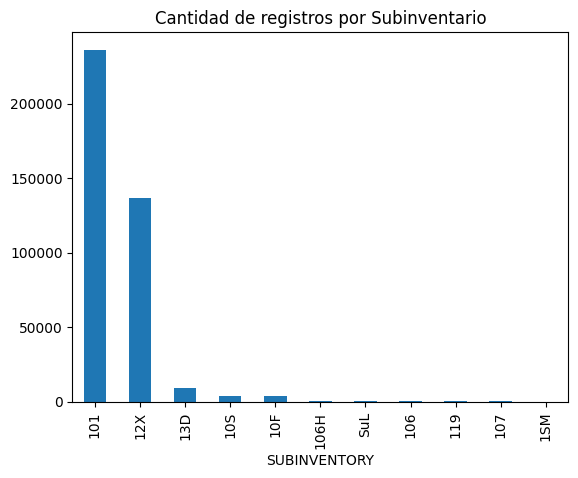

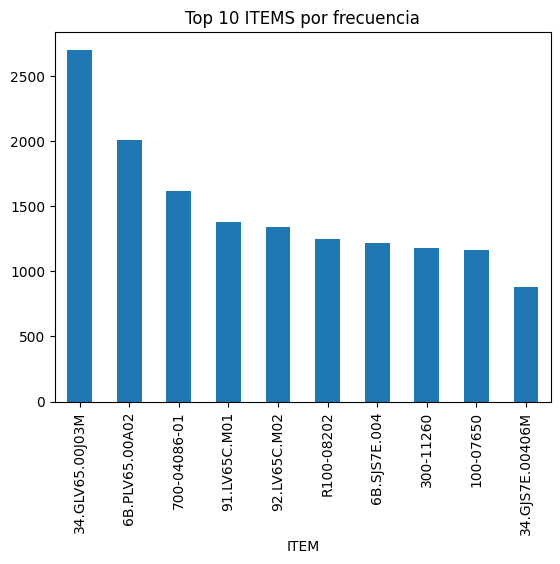

In [ ]:
pd.options.display.float_format = '{:,.0f}'.format
print("Estadística descriptiva de variables numéricas:\n")
print(df_clean[['ONHAND_QTY','RESERVED_QTY','AVAILABLE_QTY']].describe())

print("\n")
df_clean['SUBINVENTORY'].value_counts().plot(kind='bar')
plt.title("Cantidad de registros por Subinventario")
plt.show()

print("\n")
df_clean['ITEM'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 ITEMS por frecuencia")
plt.show()

## **5. Análisis bivariado**

Explorar relación entre dos variables mediante:
- scatter plot
- boxplot por categoría
- matriz de correlación

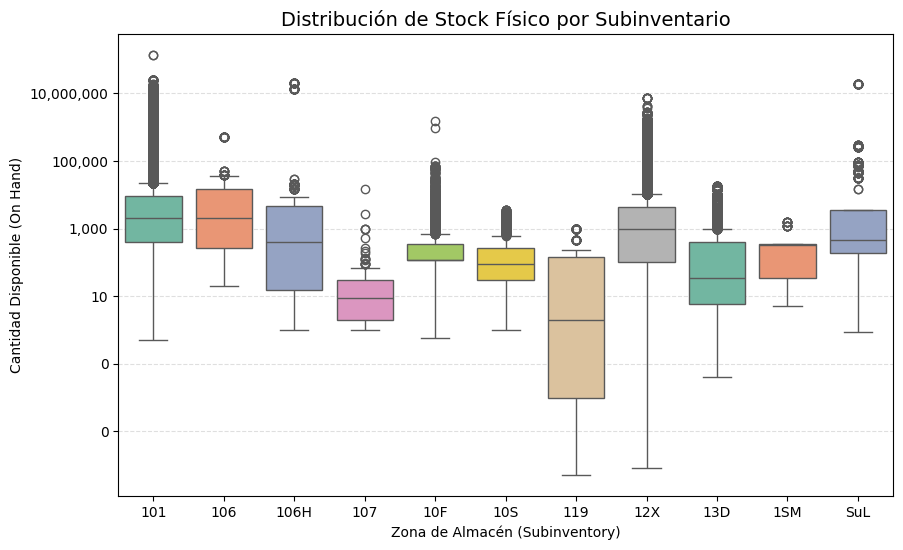

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x='SUBINVENTORY',
    y='ONHAND_QTY',
    palette='Set2',
    hue='SUBINVENTORY',
    legend=False
)

plt.yscale('log')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_major_formatter().set_useOffset(False)

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Distribución de Stock Físico por Subinventario", fontsize=14)
plt.xlabel("Zona de Almacén (Subinventory)")
plt.ylabel("Cantidad Disponible (On Hand)")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## **6. Análisis multivariado**

Explorar relaciones entre múltiples variables utilizando al menos uno:
- matriz de correlación
- pairplot
- PCA (opcional)

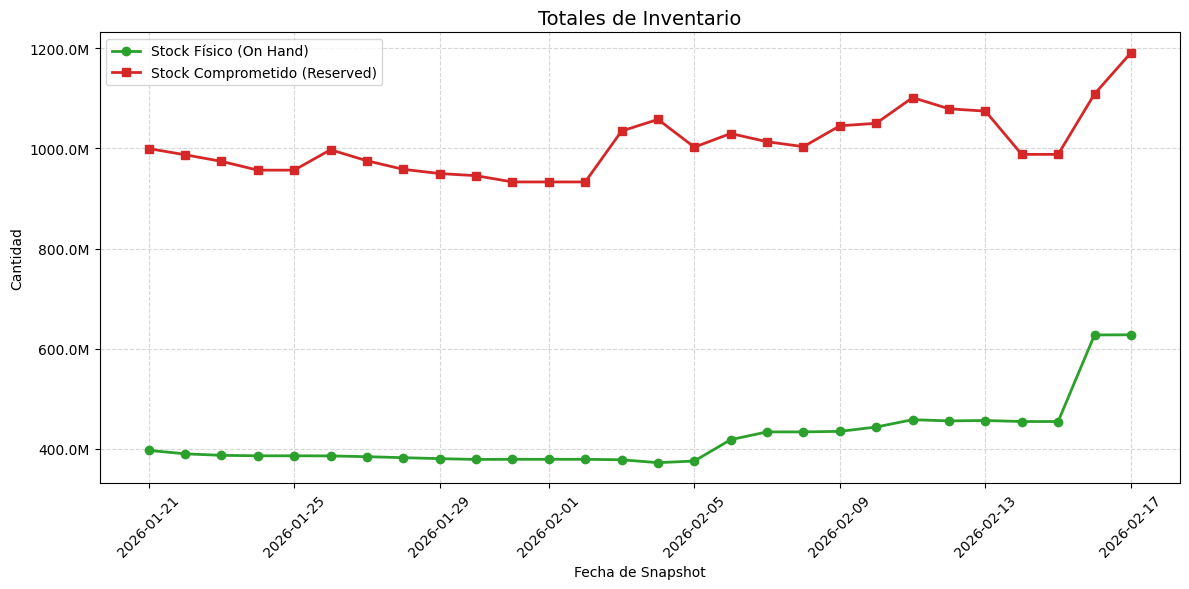

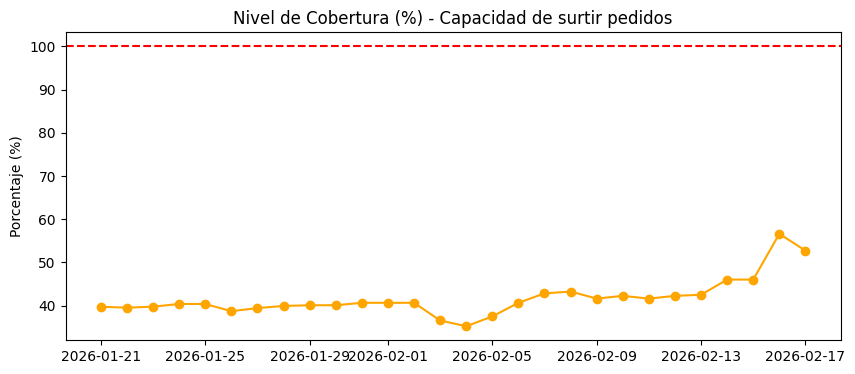

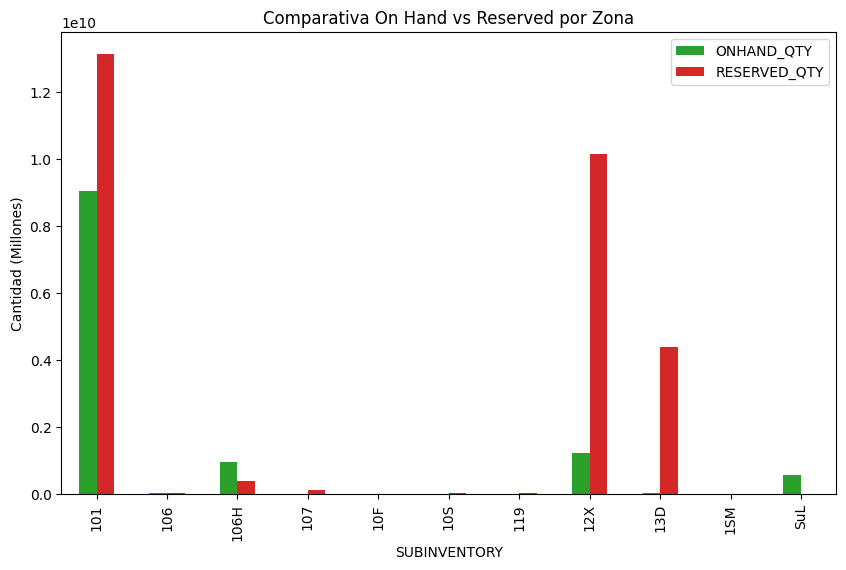

In [ ]:
df_temporal = df_clean.groupby('SNAPSHOT_DATE')[['ONHAND_QTY', 'RESERVED_QTY']].sum().reset_index()

plt.figure(figsize=(12, 6))

plt.plot(df_temporal['SNAPSHOT_DATE'], df_temporal['ONHAND_QTY'],
         marker='o', label='Stock Físico (On Hand)', linewidth=2, color='#2ca02c')

plt.plot(df_temporal['SNAPSHOT_DATE'], df_temporal['RESERVED_QTY'],
         marker='s', label='Stock Comprometido (Reserved)', linewidth=2, color='#d62728')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.title("Totales de Inventario", fontsize=14)
plt.xlabel("Fecha de Snapshot")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\n")
df_temporal['RATIO'] = df_temporal['ONHAND_QTY'] / df_temporal['RESERVED_QTY']

plt.figure(figsize=(10, 4))
plt.plot(df_temporal['SNAPSHOT_DATE'], df_temporal['RATIO'] * 100, color='orange', marker='o')
plt.axhline(100, color='red', linestyle='--') # Meta del 100%
plt.title("Nivel de Cobertura (%) - Capacidad de surtir pedidos")
plt.ylabel("Porcentaje (%)")
plt.show()

print("\n")
df_sub = df_clean.groupby('SUBINVENTORY', observed=False)[['ONHAND_QTY', 'RESERVED_QTY']].sum().reset_index()

df_sub.plot(x='SUBINVENTORY', kind='bar', figsize=(10,6), color=['#2ca02c', '#d62728'])
plt.title("Comparativa On Hand vs Reserved por Zona")
plt.ylabel("Cantidad (Millones)")
plt.show()

Actualmente, nuestro nivel de cobertura es del 40%. Esto significa que, de cada 10 pedidos que recibimos, solo tenemos mercancía lista para entregar 4; los otros 6 se quedan en espera.

Al profundizar en el almacén, detecte que este problema no es general, sino que está concentrado en tres zonas clave: el área 101, que aunque es la zona más fuerte, no se da abasto; y las zonas 12X y 13D, que están prácticamente 'vaciadas', pues deben casi diez veces más de lo que tienen físicamente.

En resumen, tenemos el inventario comprometido antes de que llegue a almacen, lo que genera un cuello de botella que frena nuestra capacidad de respuesta.

## **7. Visualizaciones para responder preguntas**

Deben incluir visualizaciones que respondan las preguntas planteadas en la primera entrega.

Para cada pregunta deben presentar:
- la pregunta
- la visualización
- una breve interpretación del resultado


PREGUNTA 1: ¿Cómo se distribuye el inventario en existencia entre subinventarios?



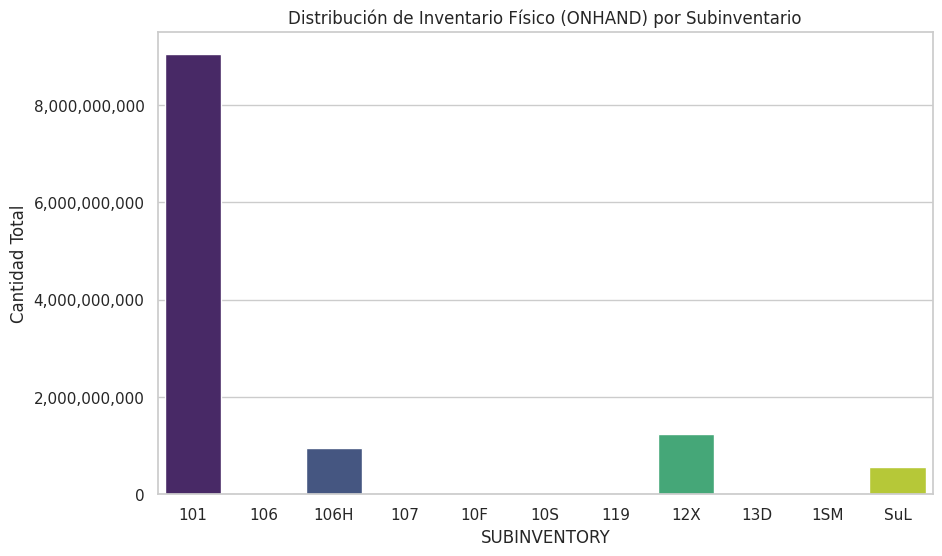


El inventario físico se concentra masivamente en el subinventario 101, que actúa como el centro operativo principal.
Las zonas 12X y 13D muestran niveles mínimos, sugiriendo que son áreas de tránsito o despacho rápido.


In [ ]:
sns.set_theme(style="whitegrid")

print("\nPREGUNTA 1: ¿Cómo se distribuye el inventario en existencia entre subinventarios?\n")

plt.figure(figsize=(10, 6))
df_sub_dist = df_clean.groupby('SUBINVENTORY', observed=False)['ONHAND_QTY'].sum().sort_values(ascending=False).reset_index()

sns.barplot(data=df_sub_dist, x='SUBINVENTORY', y='ONHAND_QTY', palette='viridis', hue='SUBINVENTORY', legend=False)
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Distribución de Inventario Físico (ONHAND) por Subinventario")
plt.ylabel("Cantidad Total")
plt.show()

print("\nEl inventario físico se concentra masivamente en el subinventario 101, que actúa como el centro operativo principal.")
print("Las zonas 12X y 13D muestran niveles mínimos, sugiriendo que son áreas de tránsito o despacho rápido.")


PREGUNTA 2: ¿Qué proporción del inventario total se encuentra reservada frente a disponible?



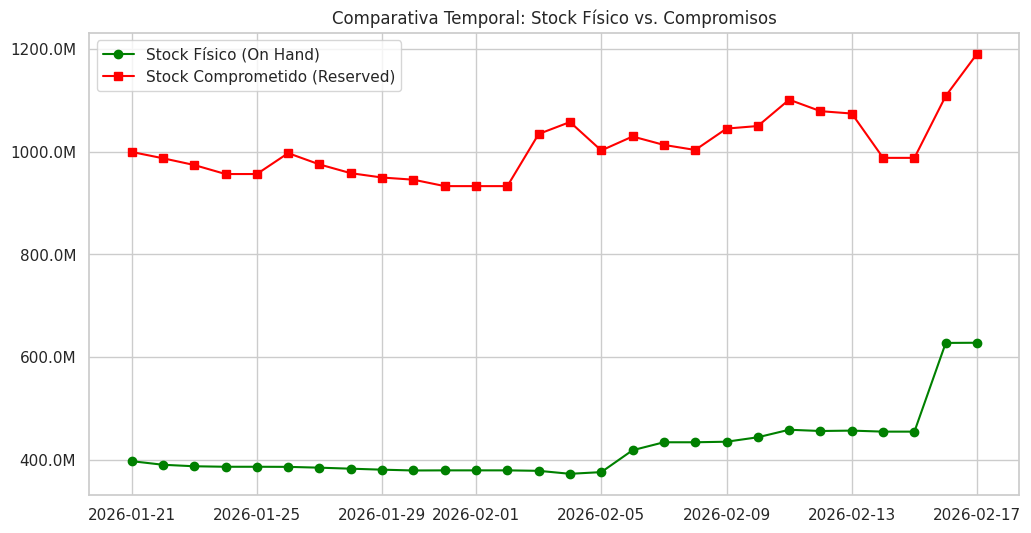


Existe un déficit crítico constante. Las reservas (1,000M) superan al stock físico (400M) en un 150%.
Esto indica que la planta opera bajo un modelo de deuda de inventario.


In [ ]:
print("\nPREGUNTA 2: ¿Qué proporción del inventario total se encuentra reservada frente a disponible?\n")

df_temp = df_clean.groupby('SNAPSHOT_DATE')[['ONHAND_QTY', 'RESERVED_QTY']].sum().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(df_temp['SNAPSHOT_DATE'], df_temp['ONHAND_QTY'], marker='o', label='Stock Físico (On Hand)', color='green')
plt.plot(df_temp['SNAPSHOT_DATE'], df_temp['RESERVED_QTY'], marker='s', label='Stock Comprometido (Reserved)', color='red')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

plt.title("Comparativa Temporal: Stock Físico vs. Compromisos")
plt.legend()
plt.show()

print("\nExiste un déficit crítico constante. Las reservas (1,000M) superan al stock físico (400M) en un 150%.")
print("Esto indica que la planta opera bajo un modelo de deuda de inventario.")


PREGUNTA 3: ¿Existen artículos con inventario en existencia pero sin disponibilidad?



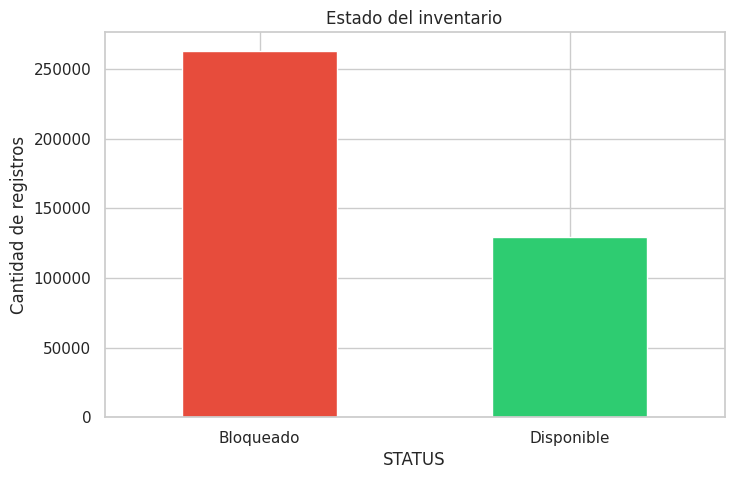


Artículos con inventario pero sin disponibilidad: 263,290
Porcentaje: 67.10%

Se identificó que una parte del inventario existente no está disponible para uso, lo que evidencia bloqueos operativos dentro del sistema.
Además, este inventario bloqueado se concentra en artículos específicos, generando ineficiencias en la utilización del stock total.


In [ ]:
print("\nPREGUNTA 3: ¿Existen artículos con inventario en existencia pero sin disponibilidad?\n")

df_status = df_clean.copy()

df_status['STATUS'] = 'Disponible'

df_status.loc[
    (df_status['ONHAND_QTY'] > 0) & (df_status['AVAILABLE_QTY'] == 0),
    'STATUS'
] = 'Bloqueado'

df_status.loc[
    df_status['ONHAND_QTY'] == 0,
    'STATUS'
] = 'Sin inventario'

status_counts = df_status['STATUS'].value_counts()

colors = {
    'Disponible': '#2ecc71',
    'Bloqueado': '#e74c3c'
}

status_counts.plot(
    kind='bar',
    figsize=(8,5),
    color=[colors[x] for x in status_counts.index]
)

plt.title("Estado del inventario")
plt.ylabel("Cantidad de registros")
plt.xticks(rotation=0)

plt.show()

blocked = df_clean[
    (df_clean['ONHAND_QTY'] > 0) &
    (df_clean['AVAILABLE_QTY'] == 0)
]

print(f"\nArtículos con inventario pero sin disponibilidad: {len(blocked):,}")
print(f"Porcentaje: {len(blocked)/len(df_clean):.2%}")

print("\nSe identificó que una parte del inventario existente no está disponible para uso, lo que evidencia bloqueos operativos dentro del sistema.")
print("Además, este inventario bloqueado se concentra en artículos específicos, generando ineficiencias en la utilización del stock total.")


PREGUNTA 4: ¿Cuáles son los artículos con mayor volumen de inventario y cómo se concentran?



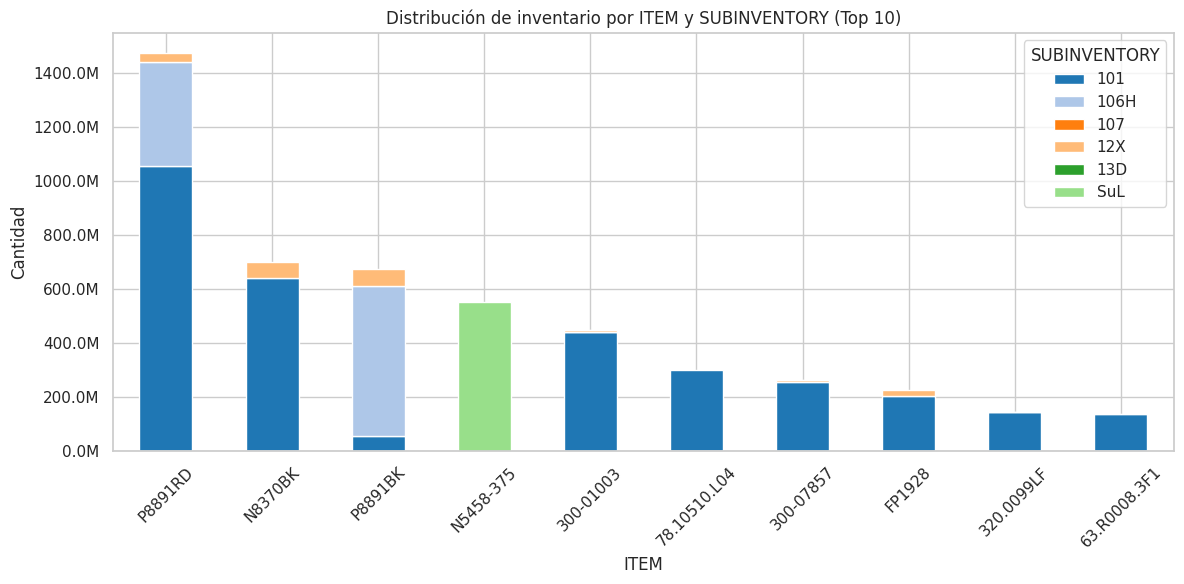


El inventario se encuentra altamente concentrado en un número reducido de artículos, donde los principales SKUs acumulan volúmenes significativamente superiores al resto.
Además, estos volúmenes se distribuyen de manera desigual entre subinventarios, evidenciando posibles acumulaciones y desbalances en la gestión del inventario.


In [ ]:
print("\nPREGUNTA 4: ¿Cuáles son los artículos con mayor volumen de inventario y cómo se concentran?\n")

pivot = (
    df_clean
    .groupby(['SUBINVENTORY', 'ITEM'], observed=True)['ONHAND_QTY']
    .sum()
    .reset_index()
)

top_items = (
    pivot.groupby('ITEM', observed=True)['ONHAND_QTY']
    .sum()
    .nlargest(10)
    .index
)

pivot_filtered = pivot[pivot['ITEM'].isin(top_items)]

pivot_bar = pivot_filtered.pivot(
    index='ITEM',
    columns='SUBINVENTORY',
    values='ONHAND_QTY'
).fillna(0)

pivot_bar_sorted = pivot_bar.loc[
    pivot_bar.sum(axis=1).sort_values(ascending=False).index
]

colors = sns.color_palette("tab20", n_colors=pivot_bar_sorted.shape[1])

ax = pivot_bar_sorted.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6),
    color=colors
)

ax.set_title("Distribución de inventario por ITEM y SUBINVENTORY (Top 10)")
ax.set_ylabel("Cantidad")

ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{x/1_000_000:.1f}M'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nEl inventario se encuentra altamente concentrado en un número reducido de artículos, donde los principales SKUs acumulan volúmenes significativamente superiores al resto.")
print("Además, estos volúmenes se distribuyen de manera desigual entre subinventarios, evidenciando posibles acumulaciones y desbalances en la gestión del inventario.")


PREGUNTA 5: ¿Cómo varía diariamente la disponibilidad del inventario?



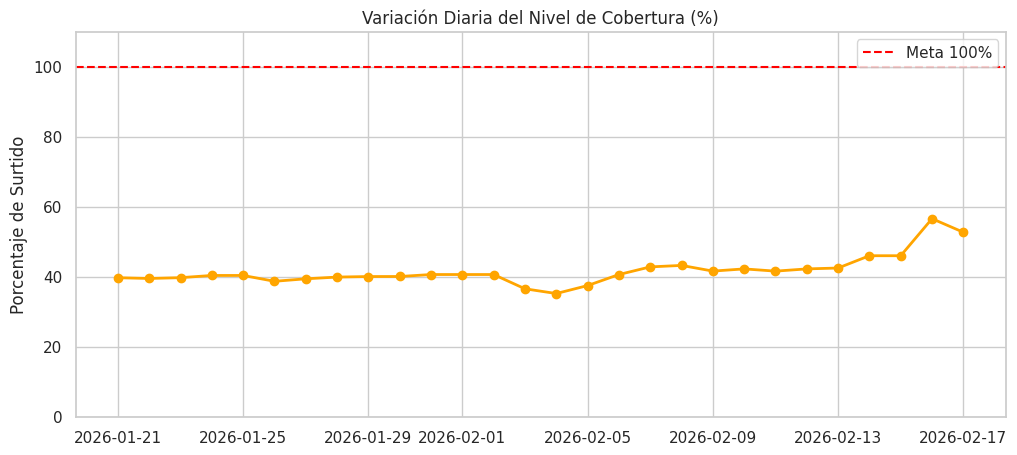


La disponibilidad es baja y estancada, rondando el 40% durante las 4 semanas.


In [ ]:
print("\nPREGUNTA 5: ¿Cómo varía diariamente la disponibilidad del inventario?\n")

df_temp['COBERTURA'] = (df_temp['ONHAND_QTY'] / df_temp['RESERVED_QTY']) * 100

plt.figure(figsize=(12, 5))
plt.plot(df_temp['SNAPSHOT_DATE'], df_temp['COBERTURA'], color='orange', marker='o', linewidth=2)
plt.axhline(100, color='red', linestyle='--', label='Meta 100%')

plt.title("Variación Diaria del Nivel de Cobertura (%)")
plt.ylabel("Porcentaje de Surtido")
plt.ylim(0, 110)
plt.legend()
plt.show()

print("\nLa disponibilidad es baja y estancada, rondando el 40% durante las 4 semanas.")


PREGUNTA 6: ¿Existen ubicaciones con alta concentración de inventario?



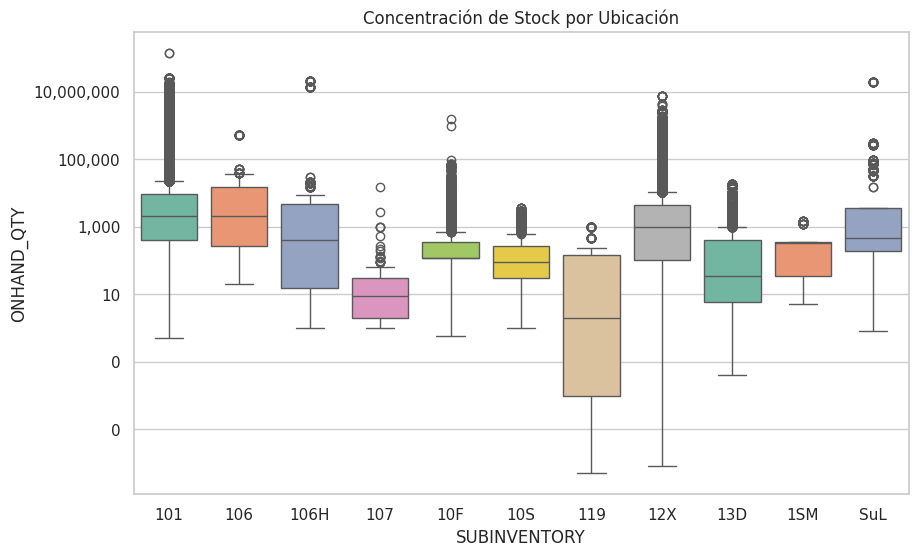


Sí. El subinventario 101 no solo tiene el mayor volumen, sino la mayor dispersión de artículos críticos.
Las zonas 12X y 13D presentan concentraciones muy bajas pero con alta saturación de reservas.


In [ ]:
print("\nPREGUNTA 6: ¿Existen ubicaciones con alta concentración de inventario?\n")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='SUBINVENTORY', y='ONHAND_QTY', palette='Set2', hue='SUBINVENTORY', legend=False)
plt.yscale('log')
ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))

plt.title("Concentración de Stock por Ubicación")
plt.show()

print("\nSí. El subinventario 101 no solo tiene el mayor volumen, sino la mayor dispersión de artículos críticos.")
print("Las zonas 12X y 13D presentan concentraciones muy bajas pero con alta saturación de reservas.")

## **8. Conclusiones**

El análisis exploratorio revela un desbalance estructural en la gestión del inventario. Aunque existe un volumen considerable de stock físico, su disponibilidad real es limitada, con un nivel de cobertura promedio cercano al 40%, lo que indica que la mayoría de la demanda no puede ser atendida de inmediato.

Se identificó que el inventario se encuentra altamente concentrado tanto en ciertos artículos como en el subinventario 101, mientras que otras zonas clave como 12X y 13D presentan niveles críticos de stock frente a altas reservas. Este comportamiento sugiere una mala distribución del inventario y posibles cuellos de botella operativos dentro del almacén.

Además, una proporción significativa del inventario (67%) se encuentra bloqueada, es decir, existe físicamente pero no está disponible para uso. Esto evidencia problemas en la gestión de reservas, asignaciones o procesos internos, generando ineficiencias y afectando directamente la capacidad de respuesta de la operación.

Finalmente, los outliers detectados no representan errores, sino acumulaciones reales de inventario en ciertos SKUs, lo que refuerza la existencia de concentración y posibles riesgos de sobrestock en artículos específicos.